In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

plt.style.use("default")

Matplotlib is building the font cache; this may take a moment.


In [12]:
fund_master = pd.read_csv("../Data/raw/01_fund_master.csv")

nav = pd.read_csv("../Data/raw/02_nav_history.csv")

aum = pd.read_csv("../Data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../Data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../Data/raw/05_category_inflows.csv")

folio = pd.read_csv("../Data/raw/06_industry_folio_count.csv")

performance = pd.read_csv("../Data/raw/07_scheme_performance.csv")

transactions = pd.read_csv("../Data/raw/08_investor_transactions.csv")

holdings = pd.read_csv("../Data/raw/09_portfolio_holdings.csv")

benchmark = pd.read_csv("../Data/raw/10_benchmark_indices.csv")

In [3]:
print(fund_master.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [4]:
print(aum.columns.tolist())


['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


In [5]:
print(sip.columns.tolist())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


In [6]:
print(category.columns.tolist())

['month', 'category', 'net_inflow_crore']


In [7]:
print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [8]:
print("AUM")
print(aum.columns.tolist())

print("\nSIP")
print(sip.columns.tolist())

print("\nCATEGORY")
print(category.columns.tolist())

print("\nHOLDINGS")
print(holdings.columns.tolist())

AUM
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

CATEGORY
['month', 'category', 'net_inflow_crore']

HOLDINGS
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

In [2]:
fund_master = pd.read_csv("../Data/raw/01_fund_master.csv")

performance = pd.read_csv("../Data/raw/07_scheme_performance.csv")

In [3]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


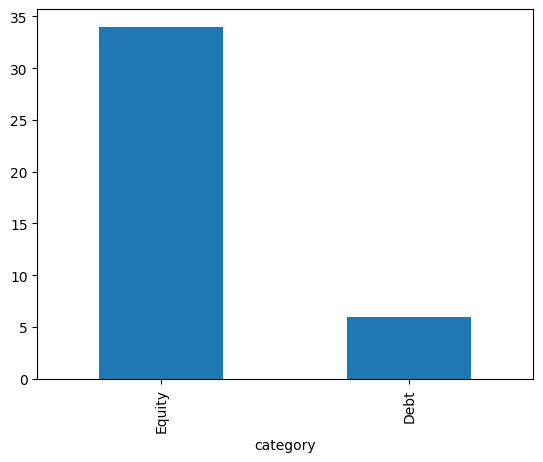

In [4]:
fund_master["category"].value_counts().plot(
    kind="bar"
)

plt.show()

Insight 1:

Large-cap and diversified equity categories have the highest number of schemes.

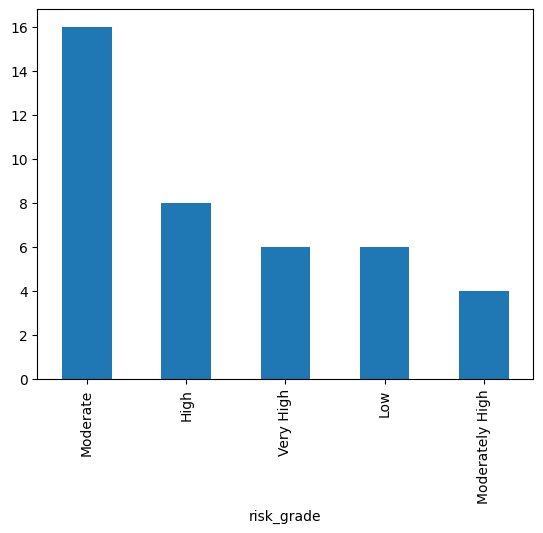

In [10]:
performance["risk_grade"].value_counts().plot(
    kind="bar"
)

plt.show()

Insight 2:

Most mutual fund schemes belong to medium and high-risk categories.

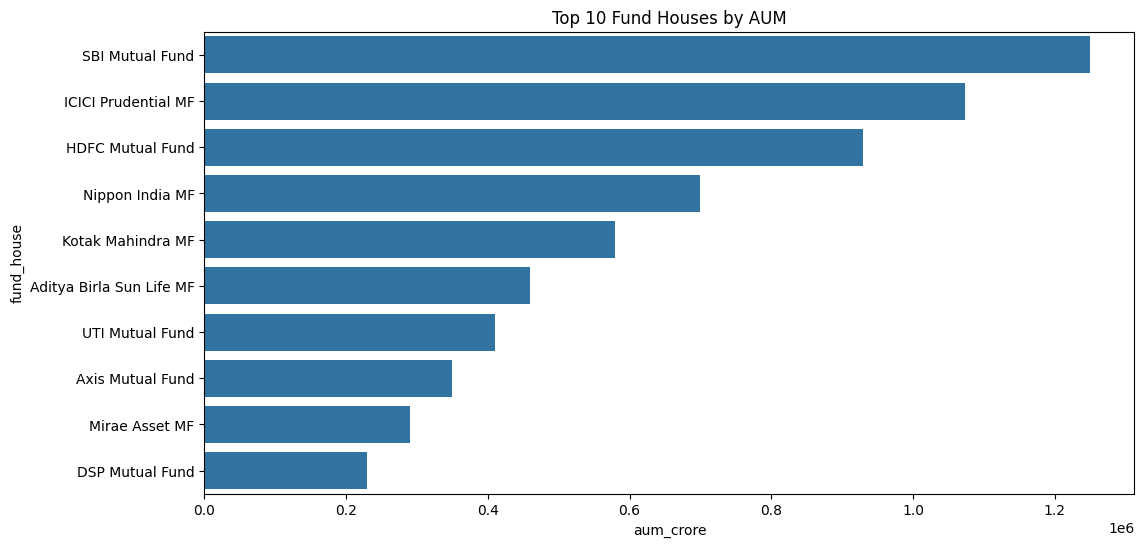

In [14]:
latest_aum = (
    aum.sort_values("date")
       .groupby("fund_house")
       .tail(1)
)

top10 = latest_aum.sort_values(
    "aum_crore",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="aum_crore",
    y="fund_house"
)

plt.title("Top 10 Fund Houses by AUM")

plt.show()

## Insight 3

A small number of fund houses control a significant portion of total mutual fund assets under management.

In [17]:
print(aum.head())

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168


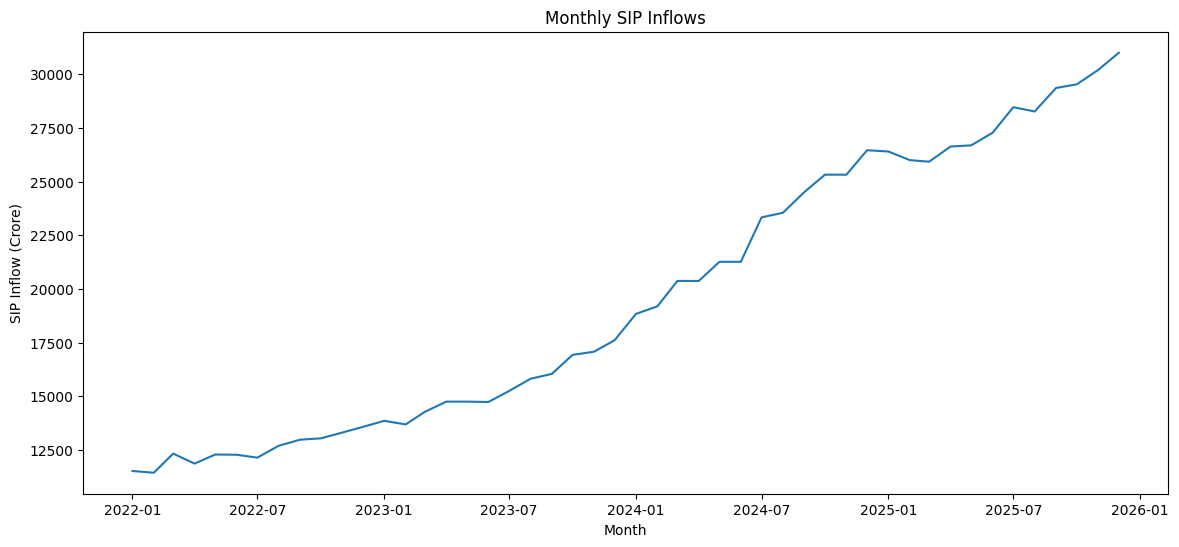

In [18]:
sip["month"] = pd.to_datetime(
    sip["month"]
)

plt.figure(figsize=(14,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"]
)

plt.title("Monthly SIP Inflows")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")

plt.show()

## Insight 4

Monthly SIP inflows have generally increased over time, showing growing retail investor participation.

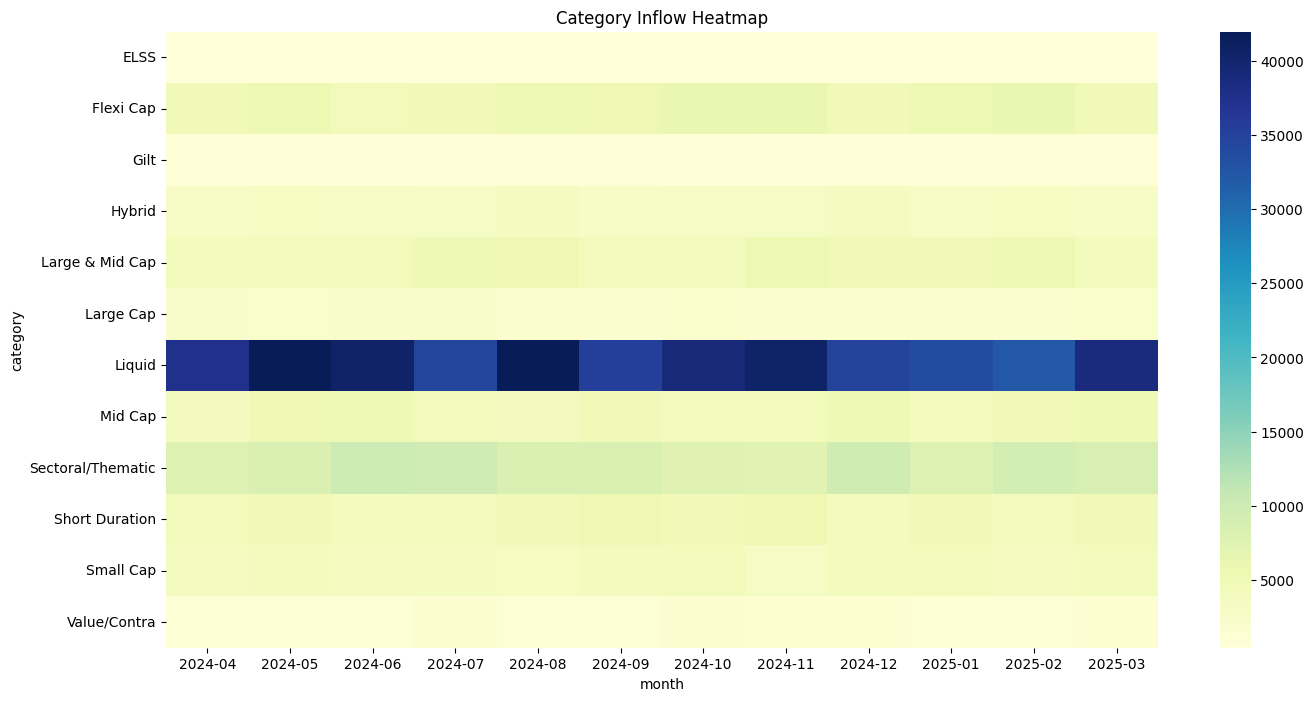

In [16]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.show()

## Insight 5

Certain mutual fund categories consistently attract higher inflows than others, reflecting changing investor preferences.

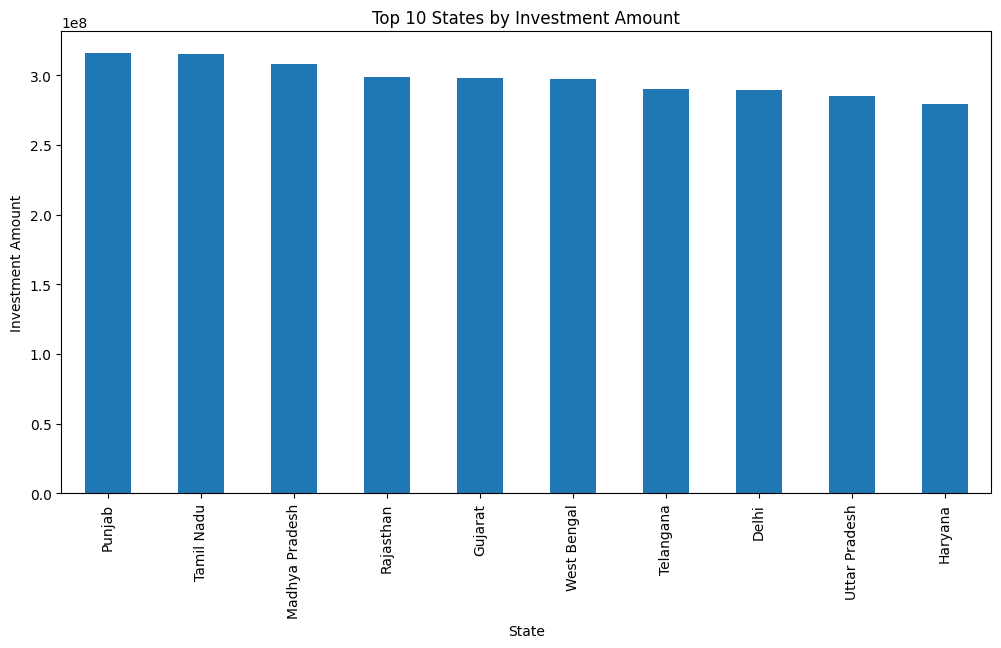

In [19]:
state_data = (
    transactions.groupby("state")
    ["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

state_data.head(10).plot(
    kind="bar"
)

plt.title("Top 10 States by Investment Amount")

plt.xlabel("State")
plt.ylabel("Investment Amount")

plt.show()

## Insight 6

A few states account for a large share of mutual fund investments.

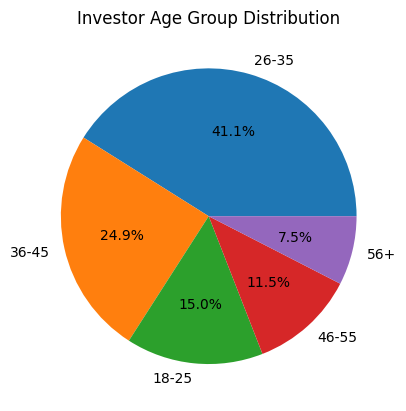

In [20]:
transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.ylabel("")

plt.show()

## Insight 7

Young and middle-aged investors represent the largest share of mutual fund participation.

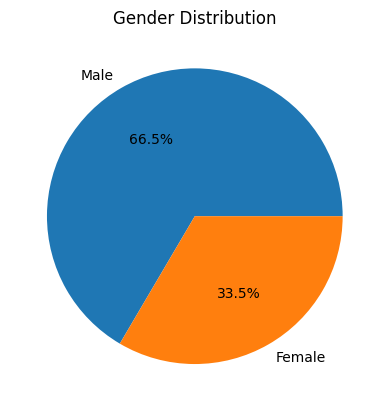

In [21]:
transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.ylabel("")

plt.show()

## Insight 8

Male and female participation shows the demographic spread of mutual fund investors.

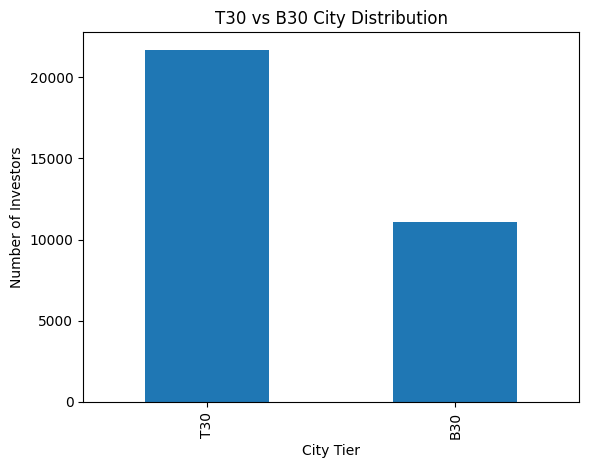

In [22]:
transactions["city_tier"].value_counts().plot(
    kind="bar"
)

plt.title("T30 vs B30 City Distribution")

plt.xlabel("City Tier")
plt.ylabel("Number of Investors")

plt.show()

## Insight 9

T30 cities contribute a larger share of mutual fund investments, though B30 participation is growing.

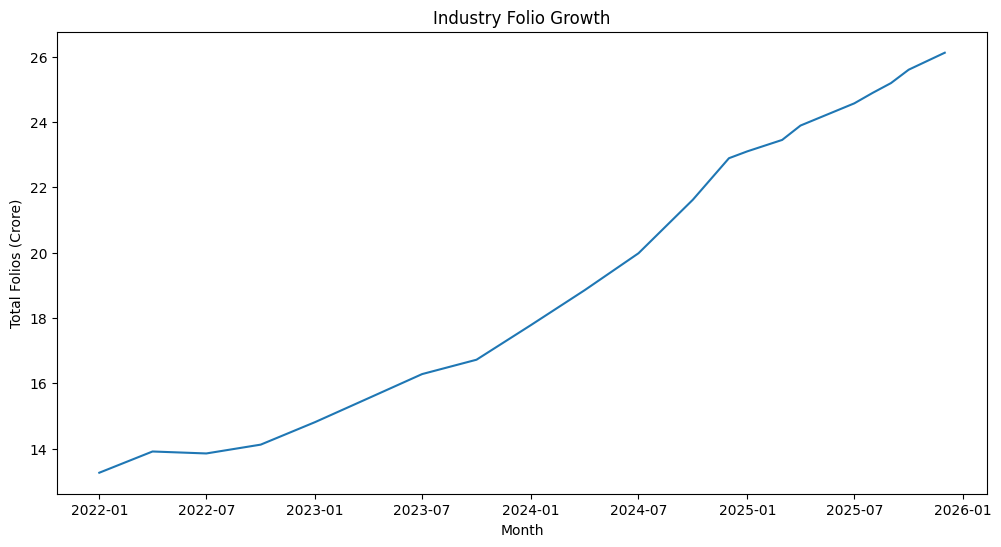

In [23]:
folio["month"] = pd.to_datetime(
    folio["month"]
)

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title("Industry Folio Growth")

plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.show()

## Insight 10

The mutual fund industry experienced strong growth in investor folios during the analysis period.